x0, p0 Sampling

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
h=1
beta=1
omega=1
m=1
rng=np.random.default_rng()

In [3]:
def sample_x0_p0(n_samples):
    x = 0.5 * beta * h * omega
    
    coth_x = np.where(
        np.abs(x) < 1e-6,
        1.0 / np.where(x == 0, 1e-12, x) + x / 3.0, 
        1.0 / np.tanh(x)
    )
    
    var_x = (h / (2.0 * m * omega)) * coth_x
    var_p = (m * h * omega / 2.0) * coth_x

    x0 = rng.normal(loc=0.0, scale=np.sqrt(var_x), size=n_samples)
    p0 = rng.normal(loc=0.0, scale=np.sqrt(var_p), size=n_samples) 

    return x0, p0, var_x, var_p


In [4]:
sample_x0_p0(1000)

(array([ 7.61431572e-02, -4.38653811e-01, -5.87839156e-02, -1.17588826e+00,
         1.07098898e+00,  4.47815551e-01, -1.42069239e+00,  1.64098527e-01,
         1.01689108e+00,  1.28433049e+00,  8.49853523e-01,  8.04702907e-01,
        -4.96868837e-01, -3.21124670e-01, -5.26544932e-01,  9.61468581e-01,
         5.96260521e-01, -1.83820407e+00,  3.23251941e-01, -6.81606536e-01,
        -7.65659982e-01, -9.60762705e-02, -7.07460719e-01, -7.06313848e-01,
         8.23394969e-01,  4.54464753e-01, -1.01939841e+00, -5.26664853e-01,
        -4.32822812e-01,  7.35724701e-01, -7.43415457e-02,  1.29881618e+00,
         4.76475351e-01,  1.53991039e-01, -1.05047604e+00,  2.04184635e+00,
        -7.52109987e-01, -6.11320472e-01,  1.52884761e+00,  1.19841745e-01,
         1.12310351e+00, -4.02689932e-01, -1.00208548e+00,  2.36279279e-01,
         1.28935182e+00, -8.55532296e-01, -2.03253330e+00, -2.55806189e-01,
         8.95507742e-02, -4.86933120e-01,  3.12995921e-01,  7.63036531e-02,
        -5.2

Testing for normal distribution

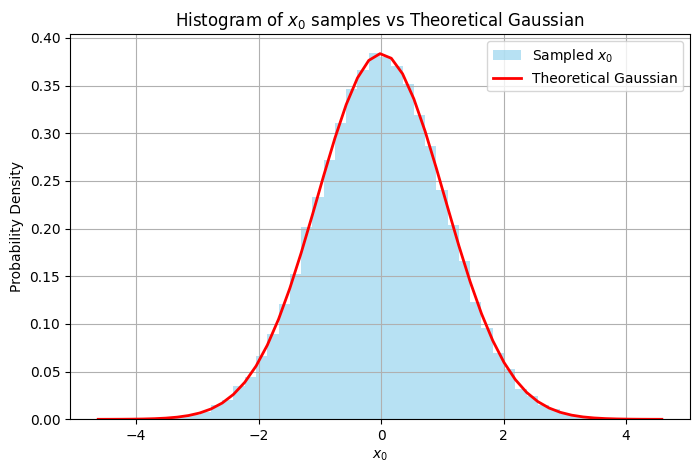

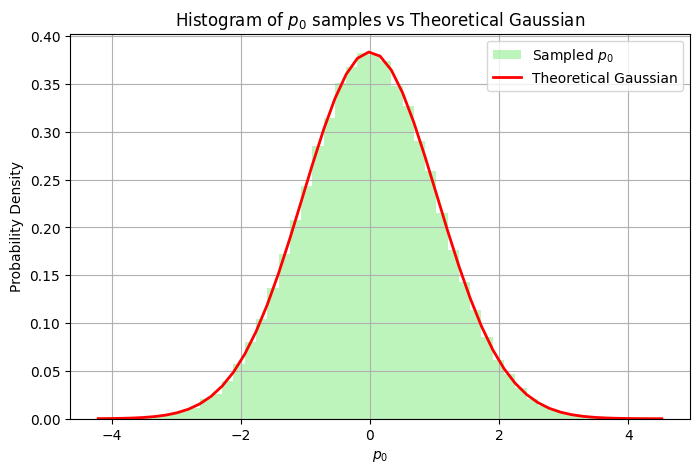

In [6]:
x0, p0, var_x, var_p = sample_x0_p0(100000)

# -------------------------------
# Plot histogram for x0
# -------------------------------
plt.figure(figsize=(8,5))
count, bins, _ = plt.hist(x0, bins=50, density=True, alpha=0.6, color='skyblue', label='Sampled $x_0$')
pdf = norm.pdf(bins, 0, np.sqrt(var_x))
plt.plot(bins, pdf, 'r-', lw=2, label='Theoretical Gaussian')
plt.title("Histogram of $x_0$ samples vs Theoretical Gaussian")
plt.xlabel("$x_0$")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------
# Plot histogram for p0
# -------------------------------
plt.figure(figsize=(8,5))
count, bins, _ = plt.hist(p0, bins=50, density=True, alpha=0.6, color='lightgreen', label='Sampled $p_0$')
pdf = norm.pdf(bins, 0, np.sqrt(var_p))
plt.plot(bins, pdf, 'r-', lw=2, label='Theoretical Gaussian')
plt.title("Histogram of $p_0$ samples vs Theoretical Gaussian")
plt.xlabel("$p_0$")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()